# MiniGrid-Fetch-5x5-N2-v0 — Model Comparison

Trains **4 variants** back-to-back, then overlays training curves, prints an evaluation table, and saves episode grids + GIFs for each variant.

| Variant | Fusion | memo + text | Reward |
|---------|-------|----------|--------|
| `baseline`  | Non | OFF  | sparse |
| `memo_text`  | Concat | ON | sparse |
| `film_dense`   | FiLM          | ON  | dense  |
| `film_sparse`  | FiLM          | ON  | sparse |


## 1 · Imports and configuration

In [ ]:
import os, sys, csv, random, time
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import torch_ac
import yaml
import matplotlib.pyplot as plt

# Add the project root to sys.path so local utility modules are importable
ROOT = Path(os.getcwd())
sys.path.insert(0, str(ROOT))

from utils.format import get_obss_preprocessor
from utils.env import make_env
from utils.plotting import (format_update_log, plot_training_curves,
                                   record_episode, show_animations,
                                   save_gifs, show_episode_grid)
from utils.model_baseline import ACModel as BaselineACModel
from utils.model_film import ACModel as FilmACModel

# Load hyperparameters and environment settings from the shared YAML config file
with open(ROOT / 'config.YAML') as f:
    CFG = yaml.safe_load(f)

SEED   = CFG['seed']
env_id = "MiniGrid-Fetch-5x5-N2-v0"
ppo    = CFG['ppo']
rew    = CFG['reward']

# Fix all random-number generators for reproducibility across runs
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Select GPU if available; otherwise fall back to CPU
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Device : {DEVICE}')
print(f'Env    : {env_id}')
print(f'Seed   : {SEED}')
print(f'Frames : {ppo["frames_max"]:,}')

Device : cpu
Env    : MiniGrid-Fetch-5x5-N2-v0
Seed   : 1
Frames : 5,000,000


## 2 · Shared vocab, preprocessing, and variant definitions

In [ ]:
# ── Shared preprocessing + action space ─────────────────────────────────────────
# Instantiate a temporary environment solely to derive the observation space
# and build the shared observation preprocessor used by all variants.
_tmp = make_env(env_id, dense_reward=False)
obs_space, preprocess_fn = get_obss_preprocessor(_tmp.observation_space)
action_space = _tmp.action_space
_tmp.close()

print(f"Text capacity : {obs_space['text']}")
print(f'Actions    : {action_space.n}')
print()

# ── Variant definitions ───────────────────────────────────────────────────────
# Each entry specifies a model architecture and reward configuration to compare.
# Fields:
#   name        – unique identifier used for directory naming and dict keys
#   label       – human-readable name shown in plots and tables
#   model_class – ACModel class to instantiate (BaselineACModel or FilmACModel)
#   use_memory  – whether to include the LSTM memory module
#   use_text    – whether to include the GRU text encoder
#   dense       – whether to use dense (shaped) reward instead of sparse reward
#   color       – matplotlib colour used consistently across all plots
VARIANTS = [
    {
        'name':        'baseline_nm',
        'label':       'Baseline',
        'model_class': BaselineACModel,
        'use_memory':  False,
        'use_text':    False,
        'dense':       False,
        'color':       'darkorange',
    },

    {
        'name':        'memo_text',
        'label':       'Memory + text=ON',
        'model_class': BaselineACModel,
        'use_memory':  True,
        'use_text':    True,
        'dense':       False,
        'color':       'steelblue',
    },

    {
        'name':        'film_sparse',
        'label':       'FiLM  sparse reward',
        'model_class': FilmACModel,
        'use_memory':  True,
        'use_text':    True,
        'dense':       False,
        'color':       'crimson',
    },

    {
        'name':        'film_dense',
        'label':       'FiLM  dense reward',
        'model_class': FilmACModel,
        'use_memory':  True,
        'use_text':    True,
        'dense':       True,
        'color':       'seagreen',
    },
]

# Preview parameter counts and model structure
print(f'{"Variant":<22}  {"Params":>10}')
print('-' * 35)
for v in VARIANTS:
    m = v['model_class'](
        obs_space, action_space,
        use_memory=v['use_memory'], use_text=v['use_text'],
    )
    n = sum(p.numel() for p in m.parameters())
    print(f"{v['label']:<22}  {n:>10,}")
    print(f"\nModel structure:\n{m}\n")
    del m

Text capacity : 100
Actions    : 7

Variant                     Params
-----------------------------------
Baseline                    19,384

Model structure:
ACModel(
  (image_conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(2, 2), stride=(1, 1))
    (4): ReLU()
    (5): Conv2d(32, 64, kernel_size=(2, 2), stride=(1, 1))
    (6): ReLU()
  )
  (actor): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=7, bias=True)
  )
  (critic): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

Memory + text=ON           134,456

Model structure:
ACModel(
  (image_conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(2, 2), stride=(1, 1))
    (

## 3 · Training function

In [ ]:
# Column names written to the CSV log for each PPO update
CSV_FIELDS = ['update', 'global_step', 'mean_ep_return', 'mean_ep_len',
              'entropy', 'policy_loss', 'value_loss', 'grad_norm']


def train_variant(variant):
    """Train one variant from scratch. Returns (run_dir, csv_path, model)."""
    name      = variant['name']
    use_dense = variant['dense']

    # ── directories ───────────────────────────────────────────────────────────
    # Create a timestamped run directory to avoid overwriting previous results
    ts       = datetime.now().strftime('%d-%m-%y-%H-%M-%S')
    run_dir  = f"runs/{env_id}_{name}_seed{SEED}_{ts}"
    ckpt_dir = os.path.join(run_dir, 'checkpoints')
    csv_path = os.path.join(run_dir, 'training_log.csv')
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'='*72}")
    print(f"  {variant['label']}")
    print(f"  dir : {run_dir}")
    print(f"{'='*72}")

    # ── model ─────────────────────────────────────────────────────────────────
    # Instantiate the model and move it to the selected compute device
    model = variant['model_class'](
        obs_space, action_space,
        use_memory=variant['use_memory'],
        use_text=variant['use_text'],
    ).to(DEVICE)

    # ── PPO algo ──────────────────────────────────────────────────────────────
    # Dense-reward variants include shaped reward kwargs; sparse variants use
    # the default environment reward without any additional shaping.
    reward_kwargs = dict(
        step_penalty           = rew['step_penalty'],
        first_sight_bonus      = rew['first_sight_bonus'],
        approach_scale         = rew['approach_scale'],
        success_reward         = rew['success_reward'],
        useless_action_penalty = rew['useless_action_penalty'],
    ) if use_dense else {}

    # Each parallel environment is seeded independently to maximise diversity
    # in the training data while remaining fully reproducible.
    algo = torch_ac.PPOAlgo(
        [
            make_env(env_id, dense_reward=use_dense, seed=SEED + 10000 * i, **reward_kwargs)
            for i in range(CFG['env']['n_envs'])
        ],
        model,
        DEVICE,
        ppo['rollout_steps'],
        ppo['gamma'],
        ppo['lr'],
        ppo['gae_lambda'],
        ppo['ent_coef'],
        ppo['value_coef'],
        ppo['max_grad_norm'],
        ppo['recurrence'],
        ppo.get('optim_eps', 1e-8),
        ppo['clip_eps'],
        ppo['train_epochs'],
        ppo['batch_size'],
        preprocess_fn,
    )

    # ── CSV header ────────────────────────────────────────────────────────────
    with open(csv_path, 'w', newline='') as f:
        csv.DictWriter(f, CSV_FIELDS).writeheader()

    # ── training loop ─────────────────────────────────────────────────────────
    num_frames = 0
    update_idx = 0
    save_every = CFG['logging']['save_interval']
    t_last     = time.time()

    while num_frames < ppo['frames_max']:
        # Collect a rollout across all parallel environments
        exps, logs = algo.collect_experiences()
        # Run PPO gradient updates on the collected rollout
        upd_logs   = algo.update_parameters(exps)
        num_frames += logs['num_frames']
        update_idx += 1

        # Build the CSV row; episode-level stats may be absent when no episode
        # completed during this rollout, so an empty string is stored instead.
        row = dict(
            update         = update_idx,
            global_step    = num_frames,
            mean_ep_return = (np.mean(logs['return_per_episode'])
                              if logs['return_per_episode'] else ''),
            mean_ep_len    = (np.mean(logs['num_frames_per_episode'])
                              if logs['num_frames_per_episode'] else ''),
            entropy     = upd_logs['entropy'],
            policy_loss = upd_logs['policy_loss'],
            value_loss  = upd_logs['value_loss'],
            grad_norm   = upd_logs['grad_norm'],
        )
        with open(csv_path, 'a', newline='') as f:
            csv.DictWriter(f, CSV_FIELDS).writerow(row)

        # Periodically checkpoint the model weights
        if num_frames % save_every < logs['num_frames']:
            ckpt = os.path.join(ckpt_dir, f'model_{num_frames}.pt')
            torch.save(model.state_dict(), ckpt)

        t_now    = time.time()
        duration = t_now - t_last
        fps      = logs['num_frames'] / max(duration, 1e-6)
        t_last   = t_now
        print(format_update_log(update_idx, num_frames, fps, duration, logs, upd_logs))

    # Save the final model weights after training is complete
    ckpt_final = os.path.join(ckpt_dir, 'model_final.pt')
    torch.save(model.state_dict(), ckpt_final)
    print(f"  Saved -> {ckpt_final}")

    return run_dir, csv_path, model


## 4 · Train all variants

In [ ]:
# run_results maps each variant name to its run directory, CSV log path,
# trained model, and variant config dict for downstream evaluation and plotting.
run_results = {}   # name -> {run_dir, csv_path, model, variant}

for v in VARIANTS:
    run_dir, csv_path, trained_model = train_variant(v)
    run_results[v['name']] = {
        'run_dir':  run_dir,
        'csv_path': csv_path,
        'model':    trained_model,
        'variant':  v,
    }

print('\n\nAll variants trained.')
for name, info in run_results.items():
    print(f"  {name:<20}  {info['run_dir']}")



  Baseline
  dir : runs/MiniGrid-Fetch-5x5-N2-v0_baseline_nm_seed1_25-02-26-00-36-18
U 1 | F 004096 | FPS 3319 | D 1 | rR:μσmM 0.36 0.40 0.00 0.99 | F:μσmM 45.55 41.32 1.00 125.00 | H 1.926 | V -0.176 | pL -0.190 | vL 0.053 | ∇ 0.190
U 2 | F 008192 | FPS 3830 | D 1 | rR:μσmM 0.35 0.39 0.00 0.98 | F:μσmM 46.27 41.67 1.00 125.00 | H 1.910 | V -0.028 | pL -0.159 | vL 0.043 | ∇ 0.114
U 3 | F 012288 | FPS 3667 | D 1 | rR:μσmM 0.43 0.38 0.00 0.99 | F:μσmM 46.85 36.36 1.00 125.00 | H 1.916 | V 0.068 | pL -0.121 | vL 0.037 | ∇ 0.112
U 4 | F 016384 | FPS 3387 | D 1 | rR:μσmM 0.40 0.40 0.00 0.99 | F:μσmM 34.22 34.25 1.00 125.00 | H 1.920 | V 0.150 | pL -0.070 | vL 0.034 | ∇ 0.116
U 5 | F 020480 | FPS 3585 | D 1 | rR:μσmM 0.41 0.41 0.00 0.99 | F:μσmM 34.40 32.65 1.00 125.00 | H 1.903 | V 0.212 | pL -0.060 | vL 0.041 | ∇ 0.144
U 6 | F 024576 | FPS 1535 | D 2 | rR:μσmM 0.47 0.44 0.00 0.99 | F:μσmM 23.52 25.13 1.00 125.00 | H 1.889 | V 0.260 | pL -0.055 | vL 0.058 | ∇ 0.224
U 7 | F 028672 | FPS 141

## 5 · Comparison: training curves

Saved -> runs/comparison_curves.png


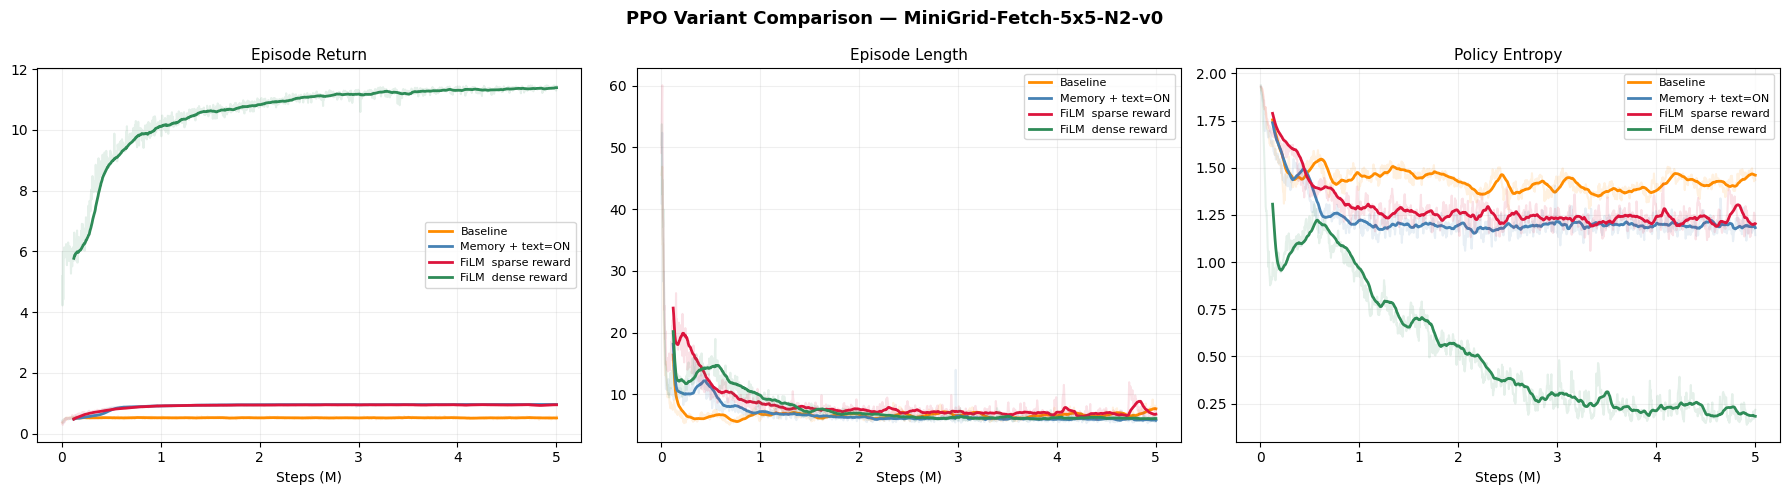

Saved -> runs/MiniGrid-Fetch-5x5-N2-v0_baseline_nm_seed1_25-02-26-00-36-18/training_curves.png


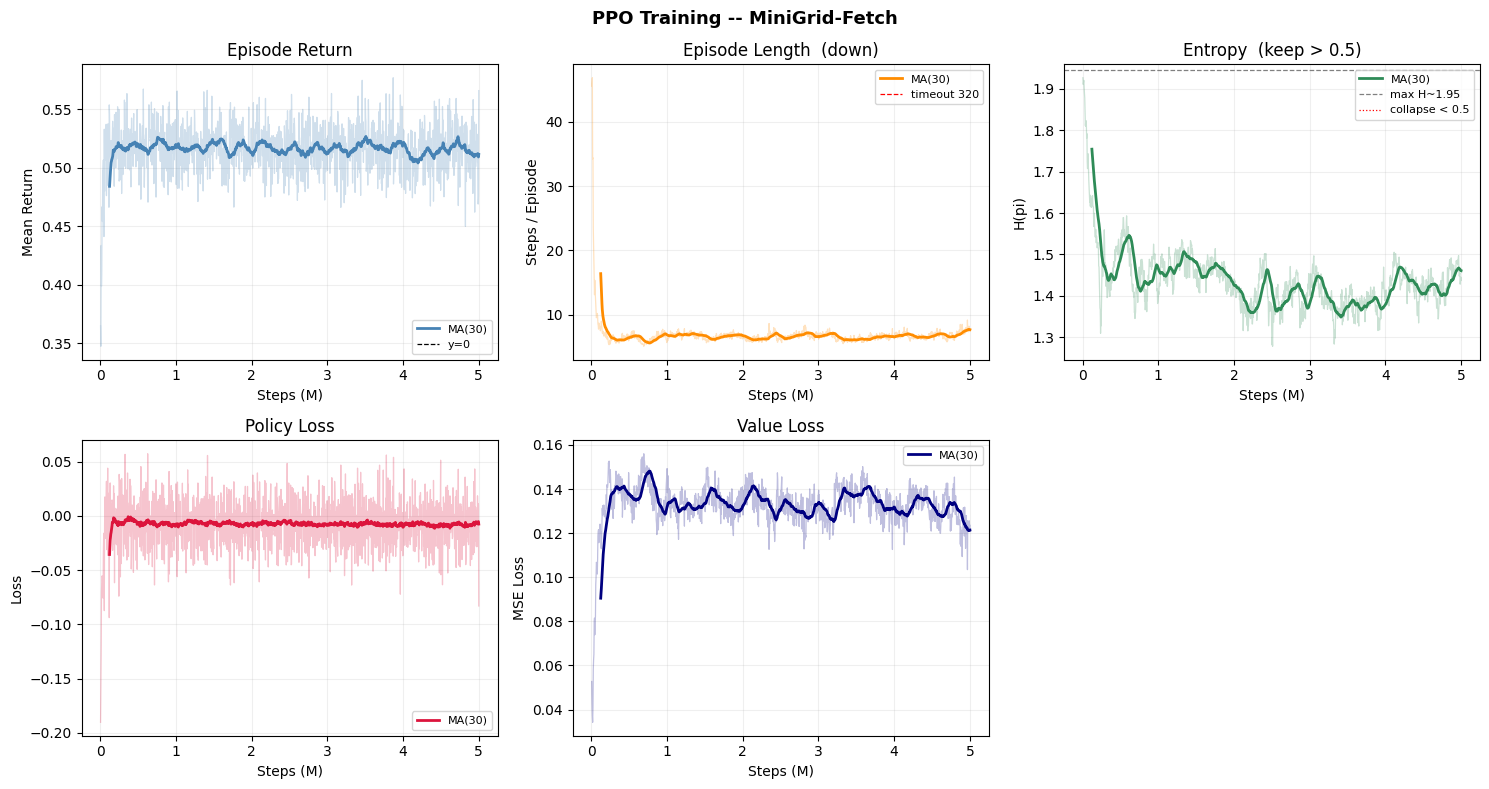


Final stats (last 50 updates):
  Return    : 0.5116
  Length    : 7.4864
  Entropy   : 1.4574
  PG Loss   : -0.0078
Saved -> runs/MiniGrid-Fetch-5x5-N2-v0_memo_text_seed1_25-02-26-01-36-07/training_curves.png


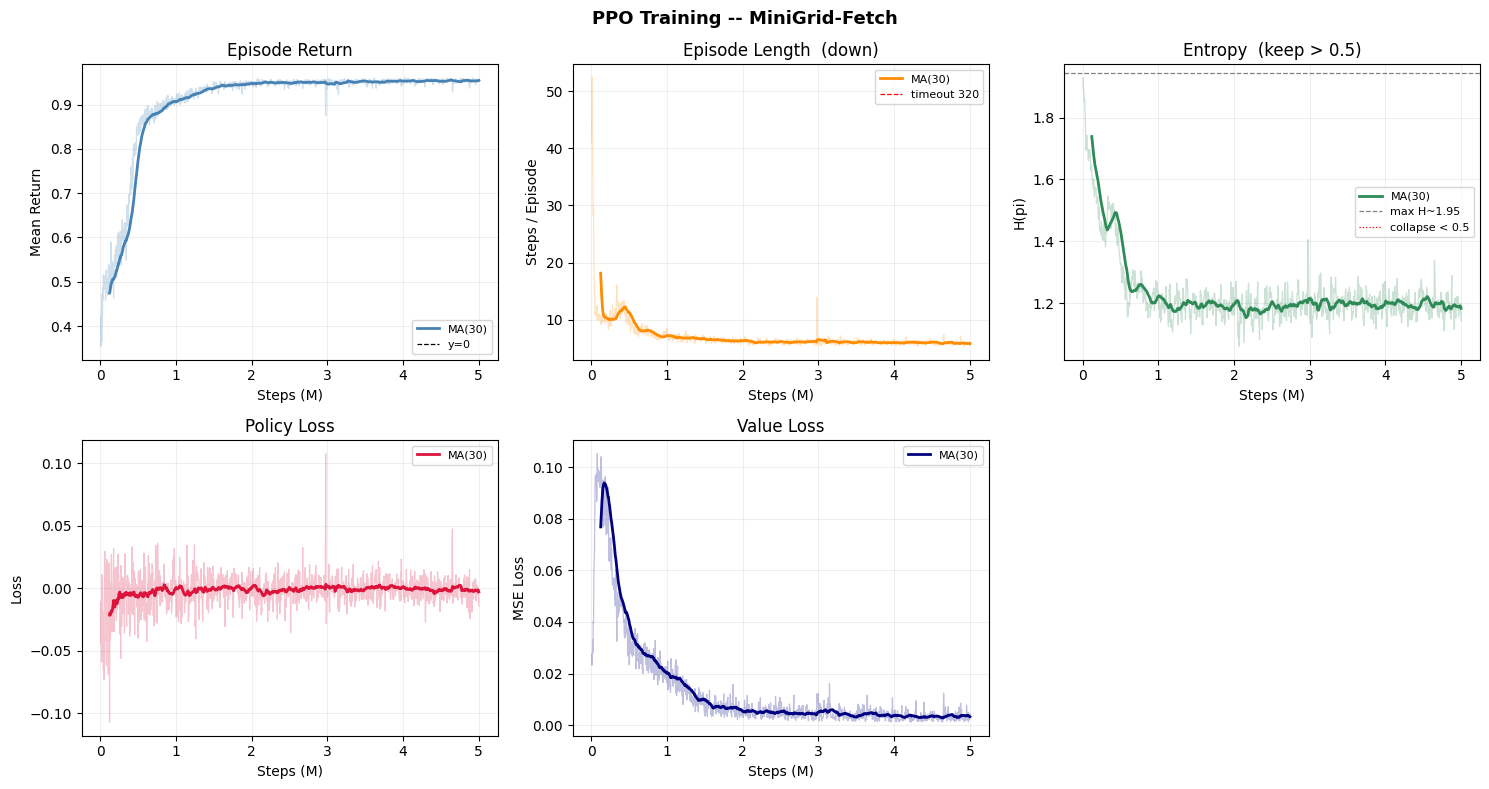


Final stats (last 50 updates):
  Return    : 0.9537
  Length    : 5.8562
  Entropy   : 1.1906
  PG Loss   : -0.0017
Saved -> runs/MiniGrid-Fetch-5x5-N2-v0_film_sparse_seed1_25-02-26-02-51-50/training_curves.png


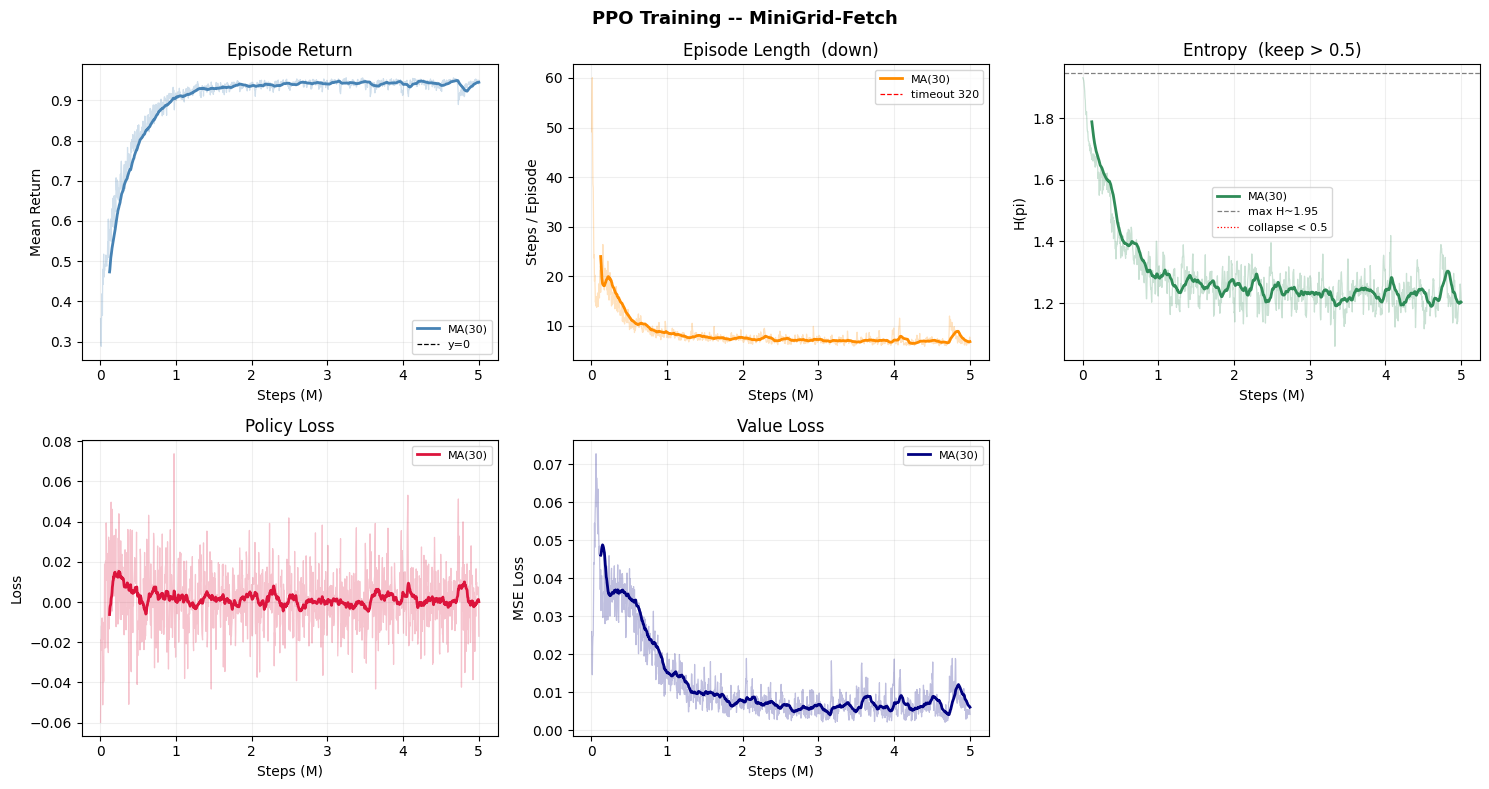


Final stats (last 50 updates):
  Return    : 0.9409
  Length    : 7.0426
  Entropy   : 1.2141
  PG Loss   : -0.0003
Saved -> runs/MiniGrid-Fetch-5x5-N2-v0_film_dense_seed1_25-02-26-04-10-22/training_curves.png


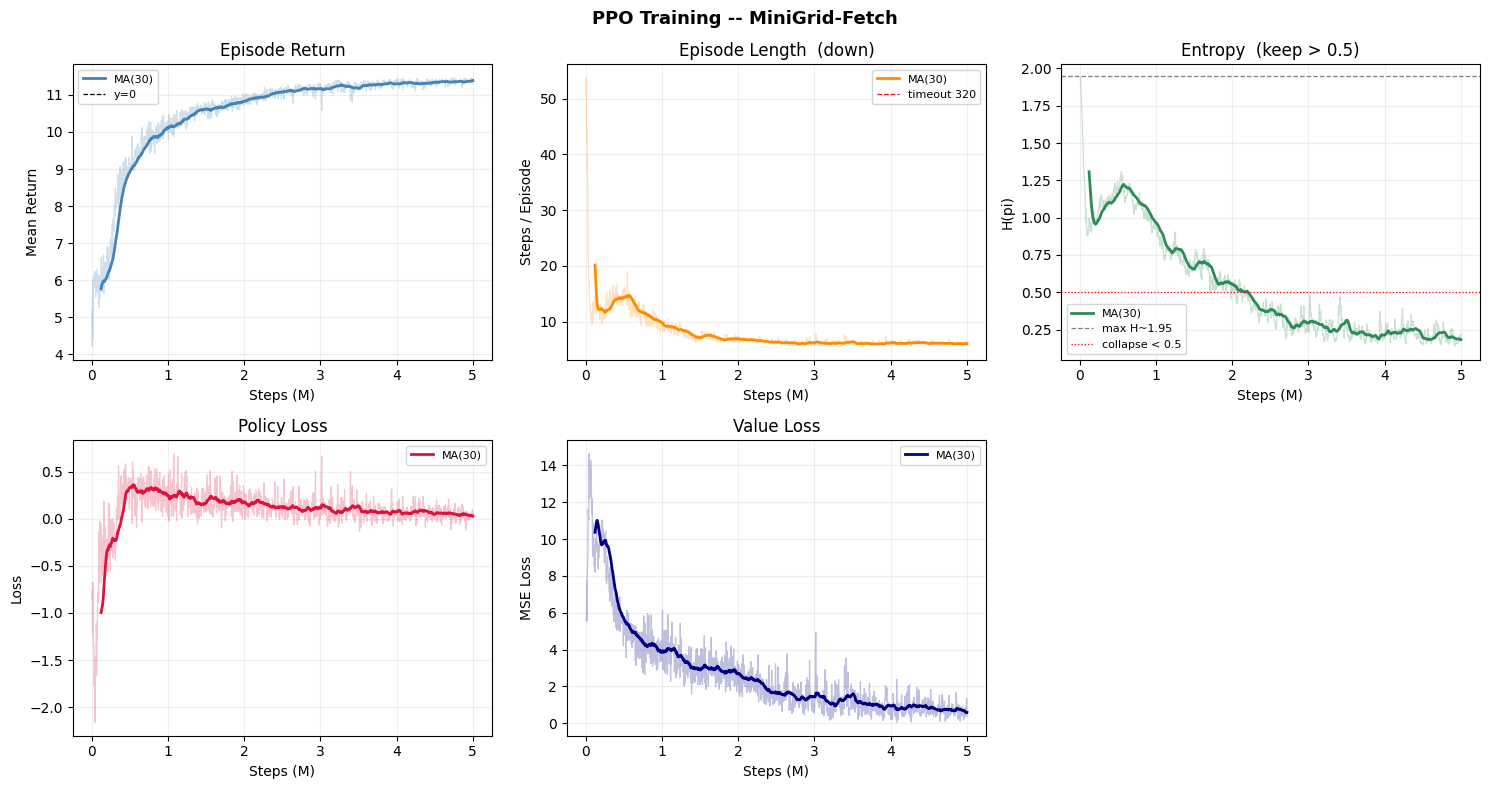


Final stats (last 50 updates):
  Return    : 11.3701
  Length    : 6.0641
  Entropy   : 0.1851
  PG Loss   : 0.0400


In [ ]:
def _col(rows, key):
    """Extract a numeric column from a list of CSV row dicts, skipping blanks."""
    return np.array([float(r[key]) for r in rows if r.get(key) not in (None, '')])

def _smooth(arr, w=30):
    """Apply a uniform moving-average of width w; returns arr unchanged if too short."""
    return np.convolve(arr, np.ones(w) / w, mode='valid') if len(arr) >= w else arr


def plot_comparison(run_results, smooth_window=30, save_path=None):
    W   = smooth_window
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'PPO Variant Comparison — {env_id}', fontsize=13, fontweight='bold')

    # Each panel plots a different training metric against environment steps
    panels = [
        ('mean_ep_return', 'Episode Return',  axes[0]),
        ('mean_ep_len',    'Episode Length',  axes[1]),
        ('entropy',        'Policy Entropy',  axes[2]),
    ]

    for name, info in run_results.items():
        v = info['variant']
        with open(info['csv_path'], newline='') as f:
            rows = list(csv.DictReader(f))
        # Convert frame count to millions for a readable x-axis
        steps = _col(rows, 'global_step') / 1e6

        for key, _, ax in panels:
            y = _col(rows, key)
            x = steps[:len(y)]
            # Plot raw (low-opacity) and smoothed (solid) curves for each variant
            ax.plot(x, y, alpha=0.12, color=v['color'])
            if len(y) >= W:
                ax.plot(x[W-1:], _smooth(y, W), color=v['color'],
                        linewidth=2, label=v['label'])

    for key, title, ax in panels:
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Steps (M)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved -> {save_path}')
    plt.show()


plot_comparison(
    run_results,
    save_path=os.path.join('runs', 'comparison_curves.png'),
)

# Also save per-variant curves
for name, info in run_results.items():
    plot_training_curves(info['csv_path'], save_dir=info['run_dir'])


## 6 · Evaluation table

In [ ]:
N_EVAL = CFG['eval']['n_episodes']

print(f"Evaluating {N_EVAL} episodes per variant (sparse reward, stochastic policy)...\n")
print(f"{'Variant':<26}  {'Return μ':>9}  {'Return σ':>9}  {'Length μ':>9}  {'Success':>8}")
print('-' * 70)

for name, info in run_results.items():
    model   = info['model']
    variant = info['variant']
    # Switch to eval mode to disable dropout / batch-norm training behaviour
    model.eval()

    ep_rets, ep_lens, successes = [], [], []
    for seed in range(N_EVAL):
        # record_episode runs one episode and returns
        # (frames, actions, success_flag, mission_string, total_return)
        _, acts, success, _, ret = record_episode(
            model, preprocess_fn, env_id, DEVICE,
            seed=seed, dense_reward=False,
        )
        ep_rets.append(ret)
        ep_lens.append(len(acts))
        successes.append(int(success))

    # Cache results so they can be reused by the visualisation cells below
    info['ep_rets']   = ep_rets
    info['ep_lens']   = ep_lens
    info['successes'] = successes

    print(f"{variant['label']:<26}  "
          f"{np.mean(ep_rets):>9.4f}  "
          f"{np.std(ep_rets):>9.4f}  "
          f"{np.mean(ep_lens):>9.1f}  "
          f"{np.mean(successes):>8.1%}")

Evaluating 50 episodes per variant (sparse reward, stochastic policy)...

Variant                      Return μ   Return σ   Length μ   Success
----------------------------------------------------------------------
Baseline                       0.5106     0.4734        8.8     54.0%
Memory + text=ON               0.9633     0.0292        5.1    100.0%
FiLM  sparse reward            0.9528     0.0465        6.6    100.0%
FiLM  dense reward             0.9591     0.0176        5.7    100.0%


## 7 · Visualise — episode grids and GIFs

Recording 6 episodes per variant...

  [baseline_nm] seed=  0  'go get a blue key'                   13 steps  [SUCCESS]
  [baseline_nm] seed=  7  'fetch a purple ball'                 18 steps  [failed]
  [baseline_nm] seed= 42  'go fetch a yellow key'                5 steps  [failed]
  [baseline_nm] seed= 77  'go fetch a green ball'                4 steps  [SUCCESS]
  [baseline_nm] seed=123  'get a red ball'                       3 steps  [failed]
  [baseline_nm] seed=256  'fetch a green ball'                   2 steps  [failed]
  success 2/6

Saved -> runs/MiniGrid-Fetch-5x5-N2-v0_baseline_nm_seed1_25-02-26-00-36-18/episode_grid.png


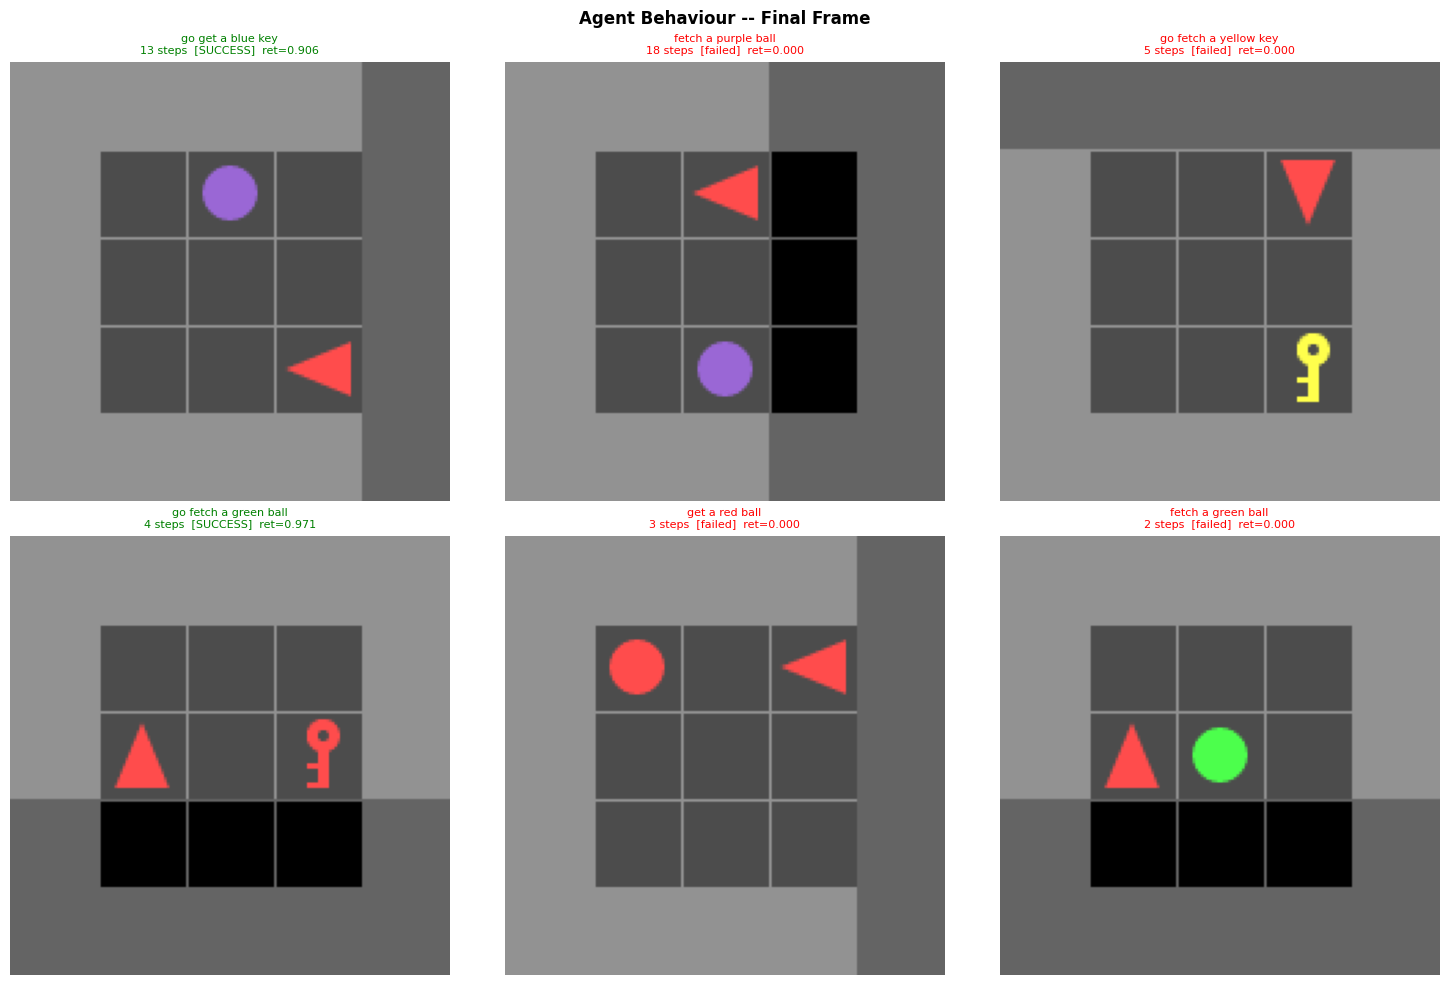

  Saved runs/MiniGrid-Fetch-5x5-N2-v0_baseline_nm_seed1_25-02-26-00-36-18/gifs/ep01_ok.gif  (14 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_baseline_nm_seed1_25-02-26-00-36-18/gifs/ep02_fail.gif  (19 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_baseline_nm_seed1_25-02-26-00-36-18/gifs/ep03_fail.gif  (6 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_baseline_nm_seed1_25-02-26-00-36-18/gifs/ep04_ok.gif  (5 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_baseline_nm_seed1_25-02-26-00-36-18/gifs/ep05_fail.gif  (4 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_baseline_nm_seed1_25-02-26-00-36-18/gifs/ep06_fail.gif  (3 frames)
  [memo_text] seed=  0  'go get a blue key'                    5 steps  [SUCCESS]
  [memo_text] seed=  7  'fetch a purple ball'                 15 steps  [SUCCESS]
  [memo_text] seed= 42  'go fetch a yellow key'                7 steps  [SUCCESS]
  [memo_text] seed= 77  'go fetch a green ball'                3 steps  [SUCCESS]
  [memo_text] seed=123  'get a red ball'    

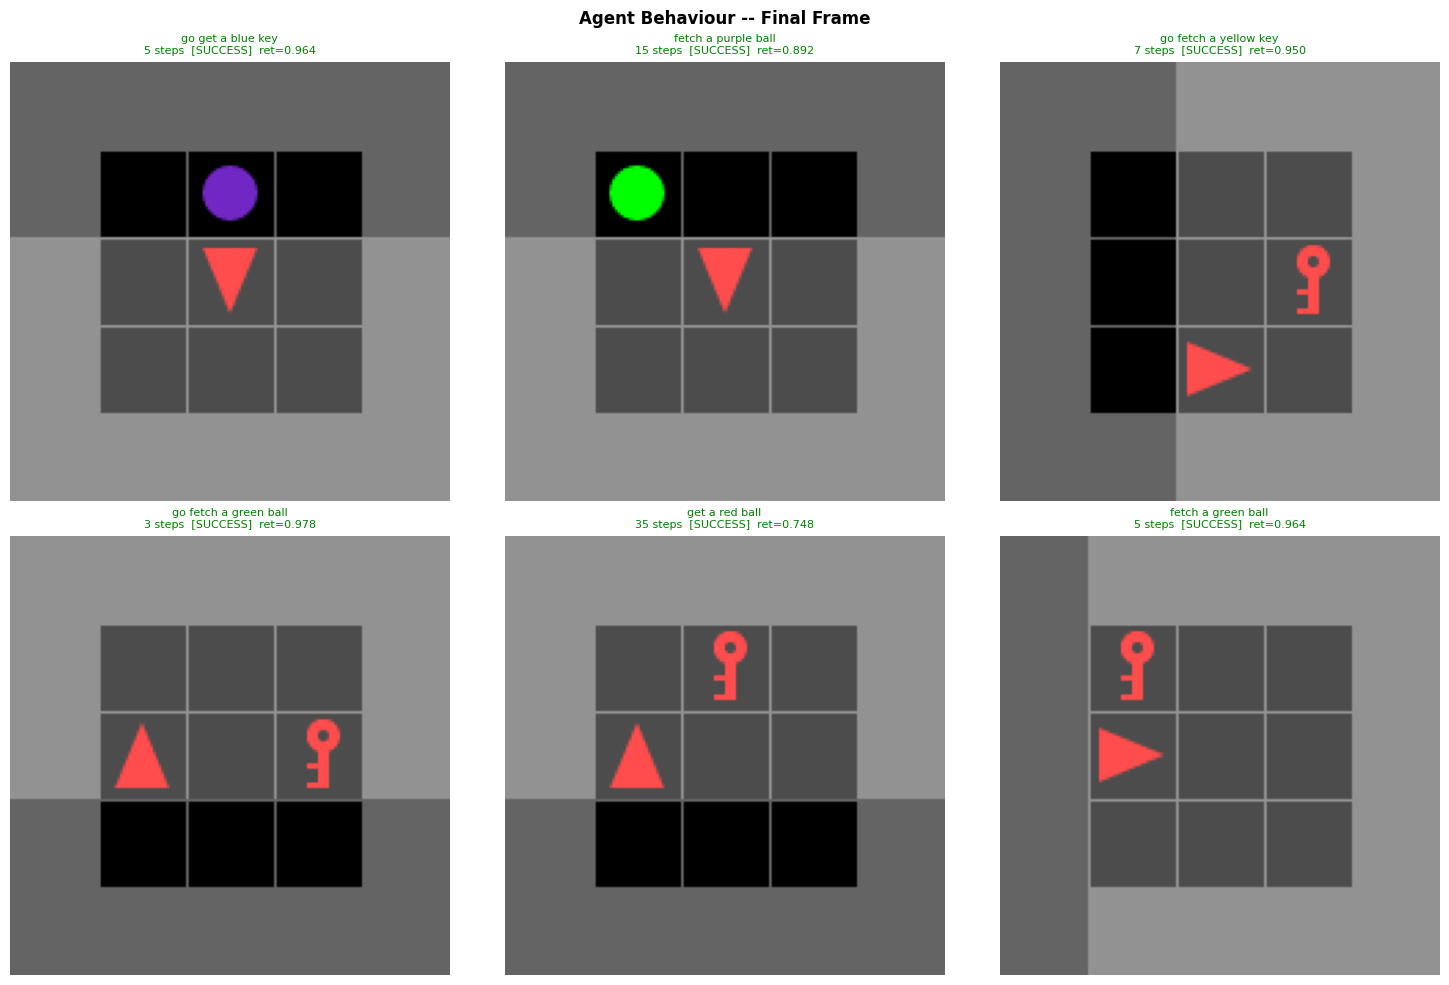

  Saved runs/MiniGrid-Fetch-5x5-N2-v0_memo_text_seed1_25-02-26-01-36-07/gifs/ep01_ok.gif  (6 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_memo_text_seed1_25-02-26-01-36-07/gifs/ep02_ok.gif  (16 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_memo_text_seed1_25-02-26-01-36-07/gifs/ep03_ok.gif  (8 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_memo_text_seed1_25-02-26-01-36-07/gifs/ep04_ok.gif  (4 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_memo_text_seed1_25-02-26-01-36-07/gifs/ep05_ok.gif  (36 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_memo_text_seed1_25-02-26-01-36-07/gifs/ep06_ok.gif  (6 frames)
  [film_sparse] seed=  0  'go get a blue key'                    3 steps  [SUCCESS]
  [film_sparse] seed=  7  'fetch a purple ball'                  7 steps  [SUCCESS]
  [film_sparse] seed= 42  'go fetch a yellow key'                7 steps  [SUCCESS]
  [film_sparse] seed= 77  'go fetch a green ball'                4 steps  [SUCCESS]
  [film_sparse] seed=123  'get a red ball'              

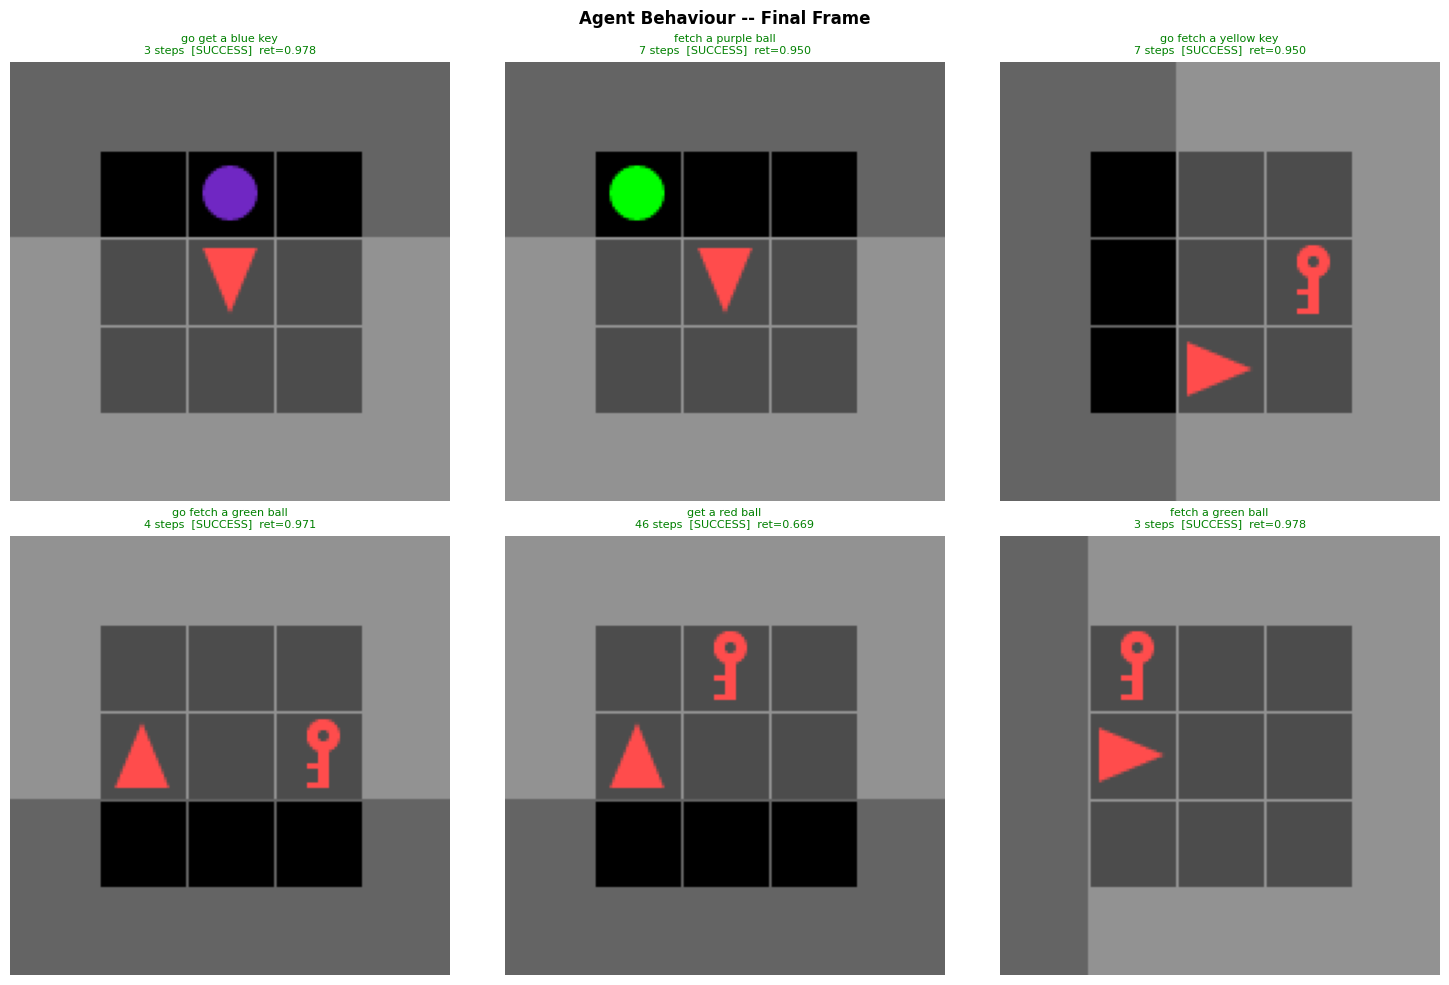

  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_sparse_seed1_25-02-26-02-51-50/gifs/ep01_ok.gif  (4 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_sparse_seed1_25-02-26-02-51-50/gifs/ep02_ok.gif  (8 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_sparse_seed1_25-02-26-02-51-50/gifs/ep03_ok.gif  (8 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_sparse_seed1_25-02-26-02-51-50/gifs/ep04_ok.gif  (5 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_sparse_seed1_25-02-26-02-51-50/gifs/ep05_ok.gif  (47 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_sparse_seed1_25-02-26-02-51-50/gifs/ep06_ok.gif  (4 frames)
  [film_dense] seed=  0  'go get a blue key'                    9 steps  [SUCCESS]
  [film_dense] seed=  7  'fetch a purple ball'                  6 steps  [SUCCESS]
  [film_dense] seed= 42  'go fetch a yellow key'               11 steps  [SUCCESS]
  [film_dense] seed= 77  'go fetch a green ball'                6 steps  [SUCCESS]
  [film_dense] seed=123  'get a red ball'        

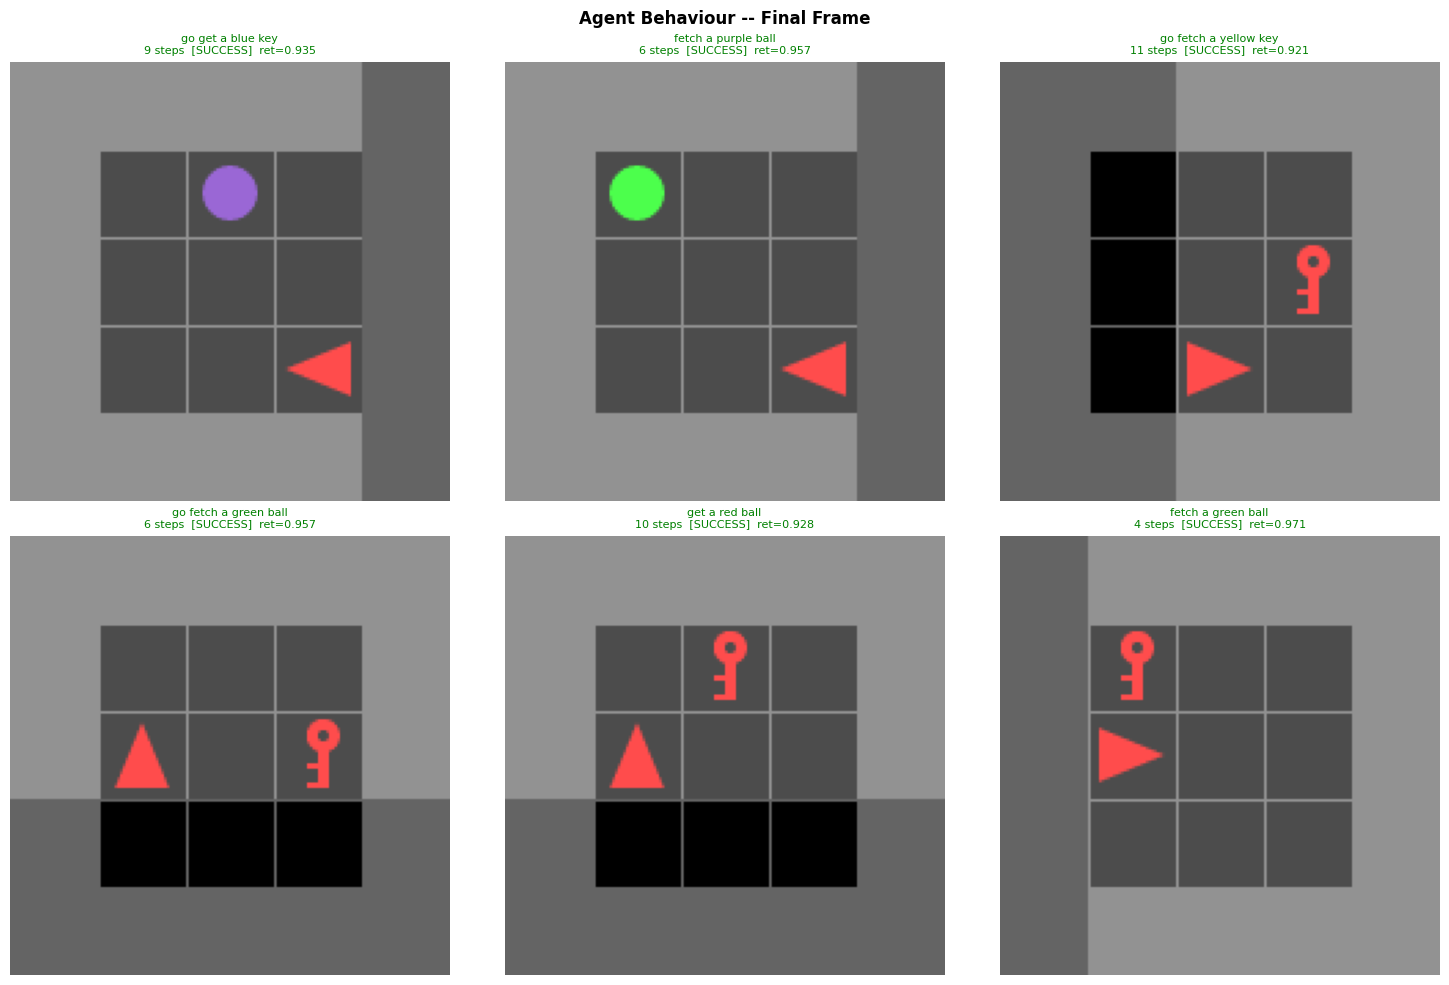

  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_dense_seed1_25-02-26-04-10-22/gifs/ep01_ok.gif  (10 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_dense_seed1_25-02-26-04-10-22/gifs/ep02_ok.gif  (7 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_dense_seed1_25-02-26-04-10-22/gifs/ep03_ok.gif  (12 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_dense_seed1_25-02-26-04-10-22/gifs/ep04_ok.gif  (7 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_dense_seed1_25-02-26-04-10-22/gifs/ep05_ok.gif  (11 frames)
  Saved runs/MiniGrid-Fetch-5x5-N2-v0_film_dense_seed1_25-02-26-04-10-22/gifs/ep06_ok.gif  (5 frames)


In [ ]:
RECORD_SEEDS = CFG['eval']['seeds']

print(f"Recording {len(RECORD_SEEDS)} episodes per variant...\n")

for name, info in run_results.items():
    model   = info['model']
    variant = info['variant']
    model.eval()

    episodes = []
    for seed in RECORD_SEEDS:
        # record_episode returns (frames, actions, success, mission, total_return)
        result = record_episode(
            model, preprocess_fn, env_id, DEVICE,
            seed=seed, dense_reward=False,
        )
        _, acts, success, mission, ret = result
        tag = 'SUCCESS' if success else 'failed'
        print(f"  [{name}] seed={seed:3d}  {mission!r:<35}  {len(acts):3d} steps  [{tag}]")
        episodes.append(result)

    sr = sum(e[2] for e in episodes)
    print(f"  success {sr}/{len(episodes)}\n")

    # Save a grid image showing the first frame of each recorded episode
    show_episode_grid(
        episodes,
        save_path=os.path.join(info['run_dir'], 'episode_grid.png'),
    )
    # Export each episode as an animated GIF for qualitative inspection
    save_gifs(
        episodes,
        gif_dir = os.path.join(info['run_dir'], 'gifs'),
        fps     = CFG['eval']['gif_fps'],
        resize  = CFG['eval']['gif_resize'],
    )

    info['episodes'] = episodes

## 8 · Inline animations

In [ ]:
# Render 2 inline HTML animations per variant for a quick visual comparison
for name, info in run_results.items():
    v = info['variant']
    print(f"\n{'─'*60}")
    print(f"  {v['label']}")
    print(f"{'─'*60}")
    show_animations(info['episodes'], n=2)



────────────────────────────────────────────────────────────
  Baseline
────────────────────────────────────────────────────────────

-- Episode 1/2  [SUCCESS]  'go get a blue key'  13 steps  ret=0.906 --



-- Episode 2/2  [failed]  'fetch a purple ball'  18 steps  ret=0.000 --



────────────────────────────────────────────────────────────
  Memory + text=ON
────────────────────────────────────────────────────────────

-- Episode 1/2  [SUCCESS]  'go get a blue key'  5 steps  ret=0.964 --



-- Episode 2/2  [SUCCESS]  'fetch a purple ball'  15 steps  ret=0.892 --



────────────────────────────────────────────────────────────
  FiLM  sparse reward
────────────────────────────────────────────────────────────

-- Episode 1/2  [SUCCESS]  'go get a blue key'  3 steps  ret=0.978 --



-- Episode 2/2  [SUCCESS]  'fetch a purple ball'  7 steps  ret=0.950 --



────────────────────────────────────────────────────────────
  FiLM  dense reward
────────────────────────────────────────────────────────────

-- Episode 1/2  [SUCCESS]  'go get a blue key'  9 steps  ret=0.935 --



-- Episode 2/2  [SUCCESS]  'fetch a purple ball'  6 steps  ret=0.957 --
